In [1]:
import pandas as pd

daily_activity = pd.read_csv("dailyActivity_merged.csv")
sleep_day = pd.read_csv("sleepDay_merged.csv")

print(daily_activity.head())
print(sleep_day.head())

           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  1503960366    4/12/2016       13162           8.50             8.50   
1  1503960366    4/13/2016       10735           6.97             6.97   
2  1503960366    4/14/2016       10460           6.74             6.74   
3  1503960366    4/15/2016        9762           6.28             6.28   
4  1503960366    4/16/2016       12669           8.16             8.16   

   LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
0                       0.0                1.88                      0.55   
1                       0.0                1.57                      0.69   
2                       0.0                2.44                      0.40   
3                       0.0                2.14                      1.26   
4                       0.0                2.71                      0.41   

   LightActiveDistance  SedentaryActiveDistance  VeryActiveMinutes  \
0                 6.06

In [3]:
# Affiche le nombre de lignes et de colonnes de chaque tableau
print("Dimensions daily_activity :", daily_activity.shape)
print("Dimensions sleep_day :", sleep_day.shape)

# Compte combien d'utilisateurs différents (Id uniques) sont présents dans chaque tableau
print("\nNombre d'utilisateurs uniques dans daily_activity :", daily_activity['Id'].nunique())
print("Nombre d'utilisateurs uniques dans sleep_day :", sleep_day['Id'].nunique())

# Vérifie s'il y a des cases vides (valeurs manquantes) dans chaque colonne
print("\nValeurs manquantes daily_activity :\n", daily_activity.isnull().sum())
print("\nValeurs manquantes sleep_day :\n", sleep_day.isnull().sum())

# Vérifie s'il y a des lignes exactement dupliquées
print("\nDoublons daily_activity :", daily_activity.duplicated().sum())
print("Doublons sleep_day :", sleep_day.duplicated().sum())

Dimensions daily_activity : (940, 15)
Dimensions sleep_day : (413, 5)

Nombre d'utilisateurs uniques dans daily_activity : 33
Nombre d'utilisateurs uniques dans sleep_day : 24

Valeurs manquantes daily_activity :
 Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

Valeurs manquantes sleep_day :
 Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64

Doublons daily_activity : 0
Doublons sleep_day : 3


In [4]:
# Supprime les 3 lignes exactement dupliquées dans sleep_day
sleep_day = sleep_day.drop_duplicates()

# Vérifie qu'il n'y a plus de doublons
print("Doublons sleep_day après nettoyage :", sleep_day.duplicated().sum())

# Convertit la colonne ActivityDate (texte) en vraie date
daily_activity['ActivityDate'] = pd.to_datetime(daily_activity['ActivityDate'], format='%m/%d/%Y')

# Convertit la colonne SleepDay (texte) en vraie date
# Le format inclut une heure (00:00:00) donc on l'extrait
sleep_day['SleepDay'] = pd.to_datetime(sleep_day['SleepDay'], format='%m/%d/%Y %I:%M:%S %p')

# Vérifie les types de colonnes après conversion
print("\nType ActivityDate :", daily_activity['ActivityDate'].dtype)
print("Type SleepDay :", sleep_day['SleepDay'].dtype)

# Nouvelle taille de sleep_day après suppression des doublons
print("\nNouvelles dimensions sleep_day :", sleep_day.shape)

Doublons sleep_day après nettoyage : 0

Type ActivityDate : datetime64[ns]
Type SleepDay : datetime64[ns]

Nouvelles dimensions sleep_day : (410, 5)


In [5]:
# On renomme SleepDay en ActivityDate pour pouvoir fusionner sur la même colonne de date
sleep_day_renamed = sleep_day.rename(columns={'SleepDay': 'ActivityDate'})

# Fusionne les deux tableaux sur Id + ActivityDate (uniquement les lignes présentes dans les deux)
merged_data = pd.merge(daily_activity, sleep_day_renamed, on=['Id', 'ActivityDate'])

# Vérifie la taille du tableau fusionné
print("Dimensions merged_data :", merged_data.shape)

# Affiche les premières lignes pour vérifier que la fusion a bien fonctionné
print(merged_data.head())

Dimensions merged_data : (410, 18)
           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  1503960366   2016-04-12       13162           8.50             8.50   
1  1503960366   2016-04-13       10735           6.97             6.97   
2  1503960366   2016-04-15        9762           6.28             6.28   
3  1503960366   2016-04-16       12669           8.16             8.16   
4  1503960366   2016-04-17        9705           6.48             6.48   

   LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
0                       0.0                1.88                      0.55   
1                       0.0                1.57                      0.69   
2                       0.0                2.14                      1.26   
3                       0.0                2.71                      0.41   
4                       0.0                3.19                      0.78   

   LightActiveDistance  SedentaryActiveDistance  VeryActi

In [6]:
# Sélectionne les colonnes clés pour l'analyse
colonnes_cles = ['TotalSteps', 'TotalDistance', 'VeryActiveMinutes', 
                  'FairlyActiveMinutes', 'LightlyActiveMinutes', 
                  'SedentaryMinutes', 'Calories', 'TotalMinutesAsleep', 'TotalTimeInBed']

# Affiche les statistiques descriptives (moyenne, min, max, écart-type, etc.)
print(merged_data[colonnes_cles].describe())

         TotalSteps  TotalDistance  VeryActiveMinutes  FairlyActiveMinutes  \
count    410.000000     410.000000         410.000000           410.000000   
mean    8514.909756       6.012390          25.046341            17.924390   
std     4157.375584       3.043946          36.218237            22.418593   
min       17.000000       0.010000           0.000000             0.000000   
25%     5188.750000       3.592500           0.000000             0.000000   
50%     8913.000000       6.270000           9.000000            11.000000   
75%    11370.250000       8.005000          38.000000            26.750000   
max    22770.000000      17.540001         210.000000           143.000000   

       LightlyActiveMinutes  SedentaryMinutes     Calories  \
count            410.000000        410.000000   410.000000   
mean             216.541463        712.100000  2389.295122   
std               86.705299        166.179395   758.435040   
min                2.000000          0.000000   2

In [7]:
# Calcule le temps passé éveillé au lit (minutes au lit moins minutes réellement endormi)
merged_data['MinutesAwakeInBed'] = merged_data['TotalTimeInBed'] - merged_data['TotalMinutesAsleep']

# Affiche la moyenne de cet indicateur
print("Moyenne minutes éveillées au lit :", merged_data['MinutesAwakeInBed'].mean())

# Calcule la corrélation entre les pas et les minutes sédentaires
correlation = merged_data['TotalSteps'].corr(merged_data['SedentaryMinutes'])
print("\nCorrélation entre TotalSteps et SedentaryMinutes :", correlation)

# Calcule la corrélation entre les pas et les minutes de sommeil
correlation2 = merged_data['TotalSteps'].corr(merged_data['TotalMinutesAsleep'])
print("Corrélation entre TotalSteps et TotalMinutesAsleep :", correlation2)

Moyenne minutes éveillées au lit : 39.30975609756098

Corrélation entre TotalSteps et SedentaryMinutes : -0.13003596276146018
Corrélation entre TotalSteps et TotalMinutesAsleep : -0.19034391666763165


In [8]:
# Calcule le temps total suivi par jour, toutes catégories confondues
merged_data['TotalMinutesTracked'] = (merged_data['VeryActiveMinutes'] + 
                                        merged_data['FairlyActiveMinutes'] + 
                                        merged_data['LightlyActiveMinutes'] + 
                                        merged_data['SedentaryMinutes'])

# Calcule le pourcentage moyen de temps passé dans chaque catégorie
pct_sedentaire = (merged_data['SedentaryMinutes'] / merged_data['TotalMinutesTracked']).mean() * 100
pct_leger = (merged_data['LightlyActiveMinutes'] / merged_data['TotalMinutesTracked']).mean() * 100
pct_modere = (merged_data['FairlyActiveMinutes'] / merged_data['TotalMinutesTracked']).mean() * 100
pct_intense = (merged_data['VeryActiveMinutes'] / merged_data['TotalMinutesTracked']).mean() * 100

print(f"Temps sédentaire : {pct_sedentaire:.1f}%")
print(f"Temps peu actif : {pct_leger:.1f}%")
print(f"Temps modérément actif : {pct_modere:.1f}%")
print(f"Temps très actif : {pct_intense:.1f}%")

Temps sédentaire : 72.7%
Temps peu actif : 22.9%
Temps modérément actif : 1.8%
Temps très actif : 2.5%


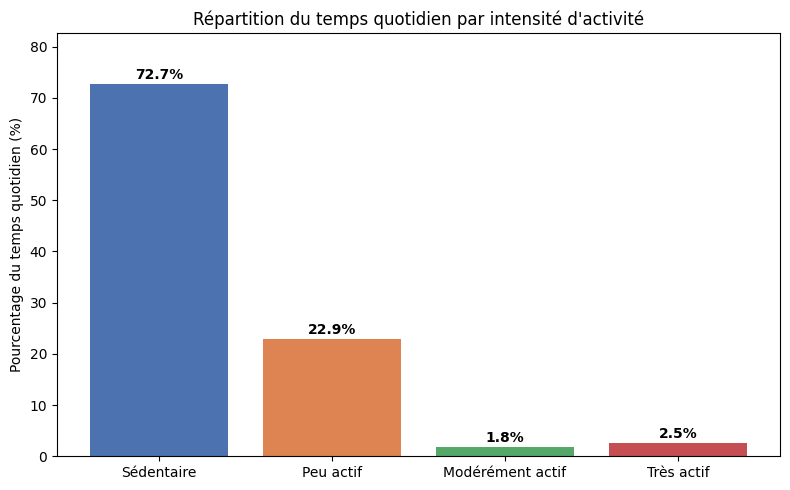

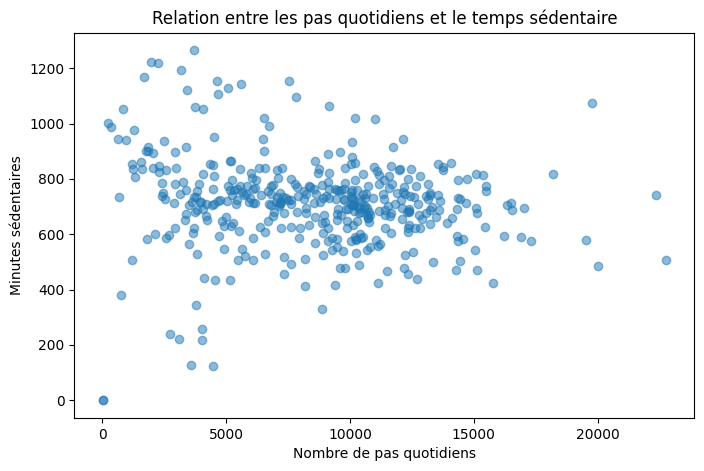

In [10]:
import matplotlib.pyplot as plt

# Graphique 1 : répartition du temps par catégorie d'activité (barres)
categories = ['Sédentaire', 'Peu actif', 'Modérément actif', 'Très actif']
valeurs = [pct_sedentaire, pct_leger, pct_modere, pct_intense]
couleurs = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

plt.figure(figsize=(8, 5))
barres = plt.bar(categories, valeurs, color=couleurs)

# Affiche le pourcentage au-dessus de chaque barre
for barre, valeur in zip(barres, valeurs):
    plt.text(barre.get_x() + barre.get_width()/2, barre.get_height() + 1, 
              f"{valeur:.1f}%", ha='center', fontweight='bold')

plt.ylabel("Pourcentage du temps quotidien (%)")
plt.title("Répartition du temps quotidien par intensité d'activité")
plt.ylim(0, max(valeurs) + 10)
plt.tight_layout()
plt.savefig("repartition_activite.png", bbox_inches='tight')
plt.show()

# Graphique 2 : relation entre pas quotidiens et minutes sédentaires (nuage de points)
plt.figure(figsize=(8, 5))
plt.scatter(merged_data['TotalSteps'], merged_data['SedentaryMinutes'], alpha=0.5)
plt.xlabel("Nombre de pas quotidiens")
plt.ylabel("Minutes sédentaires")
plt.title("Relation entre les pas quotidiens et le temps sédentaire")
plt.savefig("pas_vs_sedentaire.png")
plt.show()